In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

import warnings
warnings.filterwarnings("ignore")

# 設置中文字體
font = FontProperties(fname='msjh.ttc')

In [2]:
# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 下載台積電股價數據
ticker = yf.Ticker("2330.TW")
df = ticker.history(period="1y")
df = df[["Close"]]

In [3]:
# 數據預處理
def prepare_data(data, look_back=5, method='lookback'):
    """
    準備訓練數據
    
    Args:
        data: 原始數據
        look_back: 查看歷史天數（method='lookback' 或 'rnn' 時使用）
        method: 預測方法
            - 'single_day': 前一天預測下一天（ANN）
            - 'lookback': 前look_back天預測下一天（ANN）
            - 'rnn': 前look_back天預測下一天（RNN/LSTM）
    
    Returns:
        X, y: 特徵和標籤
        scaler: 數據縮放器
    """
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    X, y = [], []
    
    if method == 'single_day':
        # 單日預測：前一天 -> 下一天
        for i in range(len(scaled_data) - 1):
            X.append(scaled_data[i][0])  # 單個值
            y.append(scaled_data[i + 1][0])
    else:
        # Look_back預測：前look_back天 -> 下一天
        for i in range(len(scaled_data) - look_back):
            X.append(scaled_data[i : i + look_back].flatten())
            y.append(scaled_data[i + look_back][0])

    return np.array(X), np.array(y), scaler

In [4]:
# 神經網絡模型

# ANN - 單日預測版本（前一天 -> 下一天）
class ANN_SingleDay(nn.Module):
    def __init__(self):
        super(ANN_SingleDay, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.layers(x)


# ANN - Look_back預測版本（前look_back天 -> 下一天）
class ANN(nn.Module):
    def __init__(self, input_dim):
        super(ANN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 25),
            nn.ReLU(),
            nn.Linear(25, 1),
        )

    def forward(self, x):
        return self.layers(x)


class SimpleRNN_Model(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleRNN_Model, self).__init__()
        self.hidden_dim = hidden_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 重新塑造輸入張量為 (batch_size, sequence_length, input_dim)
        x = x.view(x.size(0), -1, 1)
        r_out, _ = self.rnn(x)
        predictions = self.fc(r_out[:, -1, :])
        return predictions


class LSTM_Model(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(LSTM_Model, self).__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 重新塑造輸入張量為 (batch_size, sequence_length, input_dim)
        x = x.view(x.size(0), -1, 1)
        lstm_out, _ = self.lstm(x)
        predictions = self.fc(lstm_out[:, -1, :])
        return predictions

In [5]:
# 訓練函數
def train_model(model, X_train, y_train, epochs=100, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 轉換為PyTorch張量
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train)

    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train_tensor)
        loss = criterion(outputs.squeeze(), y_train_tensor)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    return losses

In [6]:
# 主執行程序

# 準備三種方法的數據
print("=" * 60)
print("準備訓練數據...")
print("=" * 60)

# 方法1: 單日ANN (前一天 -> 下一天)
X1, y1, scaler1 = prepare_data(df["Close"].values.reshape(-1, 1), method='single_day')
X1 = X1.reshape(-1, 1)  # 確保形狀為 (n_samples, 1)

# 方法2: Look_back ANN (前look_back天 -> 下一天)
X2, y2, scaler2 = prepare_data(df["Close"].values.reshape(-1, 1), look_back=5, method='lookback')

# 方法3: Look_back RNN (前look_back天 -> 下一天)
X3, y3, scaler3 = prepare_data(df["Close"].values.reshape(-1, 1), look_back=5, method='rnn')

# 切分訓練和測試數據
def split_train_test(X, y, ratio=0.8):
    split = int(ratio * len(X))
    return X[:split], X[split:], y[:split], y[split:]

X1_train, X1_test, y1_train, y1_test = split_train_test(X1, y1)
X2_train, X2_test, y2_train, y2_test = split_train_test(X2, y2)
X3_train, X3_test, y3_train, y3_test = split_train_test(X3, y3)

# 方法1: ANN單日預測
print("\n[方法1] ANN單日預測 (前一天 -> 下一天)")
print("-" * 60)
ann_single_model = ANN_SingleDay()
ann_single_losses = train_model(ann_single_model, X1_train, y1_train, epochs=100, lr=0.01)

# 方法2: ANN Look_back預測
print("\n[方法2] ANN Look_back預測 (前5天 -> 下一天)")
print("-" * 60)
ann_lookback_model = ANN(X2_train.shape[1])
ann_lookback_losses = train_model(ann_lookback_model, X2_train, y2_train, epochs=100, lr=0.01)

# 方法3: RNN Look_back預測
print("\n[方法3] LSTM Look_back預測 (前5天 -> 下一天)")
print("-" * 60)
lstm_model = LSTM_Model(input_dim=1, hidden_dim=50)
lstm_losses = train_model(lstm_model, X3_train, y3_train, epochs=100, lr=0.01)

print("\n" + "=" * 60)
print("所有模型訓練完成!")
print("=" * 60)

準備訓練數據...

[方法1] ANN單日預測 (前一天 -> 下一天)
------------------------------------------------------------
Epoch [1/100], Loss: 0.1048
Epoch [11/100], Loss: 0.0233
Epoch [21/100], Loss: 0.0164
Epoch [31/100], Loss: 0.0123
Epoch [41/100], Loss: 0.0081
Epoch [51/100], Loss: 0.0037
Epoch [61/100], Loss: 0.0017
Epoch [71/100], Loss: 0.0015
Epoch [81/100], Loss: 0.0014
Epoch [91/100], Loss: 0.0012

[方法2] ANN Look_back預測 (前5天 -> 下一天)
------------------------------------------------------------
Epoch [1/100], Loss: 0.1533
Epoch [11/100], Loss: 0.0128
Epoch [21/100], Loss: 0.0069
Epoch [31/100], Loss: 0.0013
Epoch [41/100], Loss: 0.0015
Epoch [51/100], Loss: 0.0013
Epoch [61/100], Loss: 0.0011
Epoch [71/100], Loss: 0.0010
Epoch [81/100], Loss: 0.0009
Epoch [91/100], Loss: 0.0009

[方法3] LSTM Look_back預測 (前5天 -> 下一天)
------------------------------------------------------------
Epoch [1/100], Loss: 0.1494
Epoch [11/100], Loss: 0.0255
Epoch [21/100], Loss: 0.0178
Epoch [31/100], Loss: 0.0118
Epoch [41/100

In [7]:
# 評估模型
def evaluate_model(model, X_test, y_test, scaler, is_lstm=False):
    """
    評估模型性能
    
    Args:
        model: 訓練好的模型
        X_test: 測試特徵
        y_test: 測試標籤（已歸一化）
        scaler: MinMaxScaler 物件
        is_lstm: 是否為 LSTM 模型（不影響評估，保留向後相容性）
    
    Returns:
        mse, mae: 均方誤差和平均絕對誤差
        pred_inv: 反歸一化後的預測值
        true_inv: 反歸一化後的真實值
    """
    model.eval()
    X_test_tensor = torch.FloatTensor(X_test)

    with torch.no_grad():
        test_pred = model(X_test_tensor).numpy()

    # 反歸一化
    test_pred_inv = scaler.inverse_transform(test_pred)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

    mse = mean_squared_error(y_test_inv, test_pred_inv)
    mae = mean_absolute_error(y_test_inv, test_pred_inv)

    return mse, mae, test_pred_inv, y_test_inv


# 計算所有模型的評估指標
print("\n" + "=" * 60)
print("模型評估結果")
print("=" * 60)

# 方法1: 單日 ANN
mse1, mae1, pred1, true1 = evaluate_model(
    ann_single_model, X1_test, y1_test, scaler1
)
print("\n[方法1] ANN 單日預測")
print(f"均方誤差 (MSE): {mse1:.6f}")
print(f"平均絕對誤差 (MAE): {mae1:.6f}")

# 方法2: Look_back ANN
mse2, mae2, pred2, true2 = evaluate_model(
    ann_lookback_model, X2_test, y2_test, scaler2
)
print("\n[方法2] ANN Look_back 預測 (5天)")
print(f"均方誤差 (MSE): {mse2:.6f}")
print(f"平均絕對誤差 (MAE): {mae2:.6f}")

# 方法3: LSTM
mse3, mae3, pred3, true3 = evaluate_model(
    lstm_model, X3_test, y3_test, scaler3
)
print("\n[方法3] LSTM Look_back 預測 (5天)")
print(f"均方誤差 (MSE): {mse3:.6f}")
print(f"平均絕對誤差 (MAE): {mae3:.6f}")


模型評估結果

[方法1] ANN 單日預測
均方誤差 (MSE): 3625.748208
平均絕對誤差 (MAE): 54.859061

[方法2] ANN Look_back 預測 (5天)
均方誤差 (MSE): 695.584309
平均絕對誤差 (MAE): 21.885854

[方法3] LSTM Look_back 預測 (5天)
均方誤差 (MSE): 3888.074793
平均絕對誤差 (MAE): 55.385066


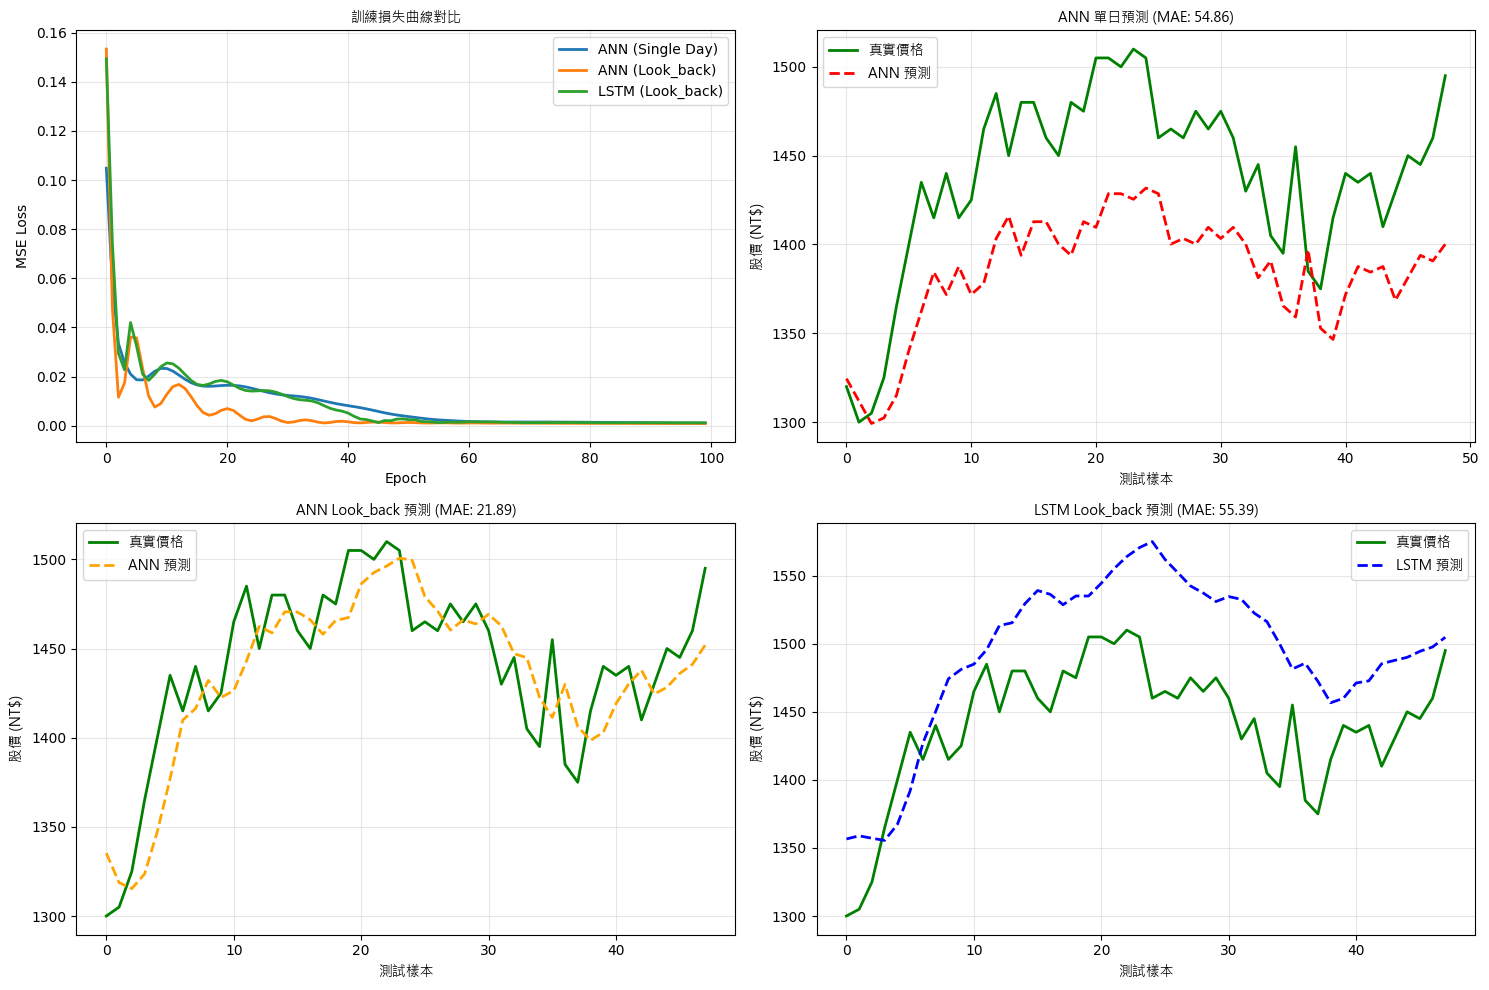


評估摘要 (Summary)
       模型         MSE   MAE
 ANN (單日) 3625.748208 54.86
 ANN (5天)  695.584309 21.89
LSTM (5天) 3888.074793 55.39


In [9]:
# 視覺化結果對比
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 訓練損失曲線比較
axes[0, 0].plot(ann_single_losses, label="ANN (Single Day)", linewidth=2)
axes[0, 0].plot(ann_lookback_losses, label="ANN (Look_back)", linewidth=2)
axes[0, 0].plot(lstm_losses, label="LSTM (Look_back)", linewidth=2)
axes[0, 0].set_title("訓練損失曲線對比", fontsize=12, fontweight='bold', fontproperties=font)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("MSE Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 方法1: 單日 ANN 預測
axes[0, 1].plot(true1, label="真實價格", color="green", linewidth=2)
axes[0, 1].plot(pred1, label="ANN 預測", color="red", linestyle="--", linewidth=2)
axes[0, 1].set_title(f"ANN 單日預測 (MAE: {mae1:.2f})", fontsize=12, fontweight='bold', fontproperties=font)
axes[0, 1].set_xlabel("測試樣本", fontproperties=font)
axes[0, 1].set_ylabel("股價 (NT$)", fontproperties=font)
axes[0, 1].legend(prop=font)
axes[0, 1].grid(True, alpha=0.3)

# 方法2: Look_back ANN 預測
axes[1, 0].plot(true2, label="真實價格", color="green", linewidth=2)
axes[1, 0].plot(pred2, label="ANN 預測", color="orange", linestyle="--", linewidth=2)
axes[1, 0].set_title(f"ANN Look_back 預測 (MAE: {mae2:.2f})", fontsize=12, fontweight='bold', fontproperties=font)
axes[1, 0].set_xlabel("測試樣本", fontproperties=font)
axes[1, 0].set_ylabel("股價 (NT$)", fontproperties=font)
axes[1, 0].legend(prop=font)
axes[1, 0].grid(True, alpha=0.3)

# 方法3: LSTM 預測
axes[1, 1].plot(true3, label="真實價格", color="green", linewidth=2)
axes[1, 1].plot(pred3, label="LSTM 預測", color="blue", linestyle="--", linewidth=2)
axes[1, 1].set_title(f"LSTM Look_back 預測 (MAE: {mae3:.2f})", fontsize=12, fontweight='bold', fontproperties=font)
axes[1, 1].set_xlabel("測試樣本", fontproperties=font)
axes[1, 1].set_ylabel("股價 (NT$)", fontproperties=font)
axes[1, 1].legend(prop=font)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 輸出評估摘要
print("\n" + "=" * 60)
print("評估摘要 (Summary)")
print("=" * 60)
summary_data = {
    "模型": ["ANN (單日)", "ANN (5天)", "LSTM (5天)"],
    "MSE": [f"{mse1:.6f}", f"{mse2:.6f}", f"{mse3:.6f}"],
    "MAE": [f"{mae1:.2f}", f"{mae2:.2f}", f"{mae3:.2f}"]
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("=" * 60)